In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data

In [3]:
circuit_eco = pd.read_csv("data/circuit_economics.csv")
construction = pd.read_csv("data/constructor_finances.csv")
standing = pd.read_csv("data/driver_standings.csv")
business = pd.read_csv("data/f1_business.csv")
results = pd.read_csv("data/race_results.csv")

# 2. Review the data

In [4]:
circuit_eco.head()

,season,grand_prix,circuit,country_iso3,region,hosting_fee_usd_m_est,weekend_attendance_k,debut_year,is_street_circuit,is_new_circuit_post_2020
0,2010,Bahrain,Sakhir,BHR,Middle East,38.5,97,2004,0,0
1,2012,Bahrain,Sakhir,BHR,Middle East,35.8,100,2004,0,0
2,2013,Bahrain,Sakhir,BHR,Middle East,34.6,94,2004,0,0
3,2014,Bahrain,Sakhir,BHR,Middle East,35.1,96,2004,0,0
4,2015,Bahrain,Sakhir,BHR,Middle East,34.2,94,2004,0,0


In [5]:
construction.head()

,season,team_name,country_iso3,operating_budget_usd_m,sponsorship_revenue_usd_m,prize_money_usd_m,total_revenue_usd_m,in_cost_cap_era,cost_cap_limit_usd_m,is_constructors_champion
0,2010,Mercedes,DEU,270.0,86.2,112.6,198.8,0,NaN,0
1,2011,Mercedes,DEU,320.5,100.2,118.4,218.6,0,NaN,0
2,2012,Mercedes,DEU,308.3,102.4,130.4,232.9,0,NaN,0
3,2013,Mercedes,DEU,356.9,126.9,158.6,285.6,0,NaN,0
4,2014,Mercedes,DEU,339.4,128.8,173.6,302.3,0,NaN,1


In [6]:
standing.head()

,season,championship_position,driver_name,country_iso3,total_points,wins,poles,podiums_est,is_world_champion
0,2010,1,Sebastian Vettel,DEU,256,5,10,9,1
1,2010,2,Fernando Alonso,ESP,252,5,2,9,0
2,2010,3,Mark Webber,AUS,242,4,5,8,0
3,2010,4,Lewis Hamilton,GBR,240,3,1,7,0
4,2010,5,Jenson Button,GBR,214,2,0,5,0


In [7]:
business.head()

,season,total_revenue_usd_m,race_promotion_fees_usd_m,broadcast_media_usd_m,sponsorship_usd_m,other_revenue_usd_m,is_liberty_media_era,drive_to_survive_viewers_m_est,us_avg_race_viewers_m,global_avg_race_viewers_m
0,2010,1108.0,399.0,377.0,177.0,155.0,0,0,0.55,70.0
1,2011,1265.0,455.0,430.0,202.0,177.0,0,0,0.55,71.5
2,2012,1377.0,496.0,468.0,220.0,193.0,0,0,0.55,73.0
3,2013,1509.0,543.0,513.0,241.0,211.0,0,0,0.55,74.5
4,2014,1728.0,622.0,588.0,276.0,242.0,0,0,0.55,76.0


In [8]:
results.head()

,race_id,season,round_number,race_date,grand_prix,circuit,country_iso3,region,pole_position,winner,podium_p2,podium_p3,fastest_lap_driver,safety_car_periods,is_sprint_weekend
0,R001,2010,1,2010-03-21,Bahrain,Sakhir,BHR,Middle East,Robert Kubica,Lewis Hamilton,Mark Webber,Oscar Piastri,Oscar Piastri,0,0
1,R002,2010,2,2010-03-15,Australia,Albert Park,AUS,Oceania,Sebastian Vettel,Fernando Alonso,Mark Webber,Valtteri Bottas,Daniel Ricciardo,1,0
2,R003,2010,3,2010-04-10,Malaysia,Sepang,MYS,Asia,Sebastian Vettel,Jenson Button,Lando Norris,Oscar Piastri,Lando Norris,1,0
3,R004,2010,4,2010-04-03,China,Shanghai,CHN,Asia,Sebastian Vettel,Fernando Alonso,Lewis Hamilton,Daniel Ricciardo,Fernando Alonso,0,0
4,R005,2010,5,2010-05-19,Spain,Barcelona,ESP,Europe,Mark Webber,Mark Webber,Lewis Hamilton,Fernando Alonso,Lewis Hamilton,1,0


In [9]:
circuit_eco.isna().sum()

season                      0
grand_prix                  0
circuit                     0
country_iso3                0
region                      0
hosting_fee_usd_m_est       0
weekend_attendance_k        0
debut_year                  0
is_street_circuit           0
is_new_circuit_post_2020    0
dtype: int64

In [10]:
construction.isna().sum()

season                         0
team_name                      0
country_iso3                   0
operating_budget_usd_m         0
sponsorship_revenue_usd_m      0
prize_money_usd_m              0
total_revenue_usd_m            0
in_cost_cap_era                0
cost_cap_limit_usd_m         104
is_constructors_champion       0
dtype: int64

In [11]:
standing.isna().sum()

season                   0
championship_position    0
driver_name              0
country_iso3             0
total_points             0
wins                     0
poles                    0
podiums_est              0
is_world_champion        0
dtype: int64

In [12]:
business.isna().sum()

season                            0
total_revenue_usd_m               0
race_promotion_fees_usd_m         0
broadcast_media_usd_m             0
sponsorship_usd_m                 0
other_revenue_usd_m               0
is_liberty_media_era              0
drive_to_survive_viewers_m_est    0
us_avg_race_viewers_m             0
global_avg_race_viewers_m         0
dtype: int64

In [13]:
results.isna().sum()

race_id               0
season                0
round_number          0
race_date             0
grand_prix            0
circuit               0
country_iso3          0
region                0
pole_position         0
winner                0
podium_p2             0
podium_p3             0
fastest_lap_driver    0
safety_car_periods    0
is_sprint_weekend     0
dtype: int64

In [14]:
results.columns

Index(['race_id', 'season', 'round_number', 'race_date', 'grand_prix',
       'circuit', 'country_iso3', 'region', 'pole_position', 'winner',
       'podium_p2', 'podium_p3', 'fastest_lap_driver', 'safety_car_periods',
       'is_sprint_weekend'],
      dtype='object')

In [15]:
mer = results.merge(business,on = "season" , how="left")

In [16]:
mer.columns

Index(['race_id', 'season', 'round_number', 'race_date', 'grand_prix',
       'circuit', 'country_iso3', 'region', 'pole_position', 'winner',
       'podium_p2', 'podium_p3', 'fastest_lap_driver', 'safety_car_periods',
       'is_sprint_weekend', 'total_revenue_usd_m', 'race_promotion_fees_usd_m',
       'broadcast_media_usd_m', 'sponsorship_usd_m', 'other_revenue_usd_m',
       'is_liberty_media_era', 'drive_to_survive_viewers_m_est',
       'us_avg_race_viewers_m', 'global_avg_race_viewers_m'],
      dtype='object')

In [17]:
mer

,race_id,season,round_number,race_date,grand_prix,circuit,country_iso3,region,pole_position,winner,...,is_sprint_weekend,total_revenue_usd_m,race_promotion_fees_usd_m,broadcast_media_usd_m,sponsorship_usd_m,other_revenue_usd_m,is_liberty_media_era,drive_to_survive_viewers_m_est,us_avg_race_viewers_m,global_avg_race_viewers_m
0,R001,2010,1,2010-03-21,Bahrain,Sakhir,BHR,Middle East,Robert Kubica,Lewis Hamilton,...,0,1108.0,399.0,377.0,177.0,155.0,0,0,0.55,70.0
1,R002,2010,2,2010-03-15,Australia,Albert Park,AUS,Oceania,Sebastian Vettel,Fernando Alonso,...,0,1108.0,399.0,377.0,177.0,155.0,0,0,0.55,70.0
2,R003,2010,3,2010-04-10,Malaysia,Sepang,MYS,Asia,Sebastian Vettel,Jenson Button,...,0,1108.0,399.0,377.0,177.0,155.0,0,0,0.55,70.0
3,R004,2010,4,2010-04-03,China,Shanghai,CHN,Asia,Sebastian Vettel,Fernando Alonso,...,0,1108.0,399.0,377.0,177.0,155.0,0,0,0.55,70.0
4,R005,2010,5,2010-05-19,Spain,Barcelona,ESP,Europe,Mark Webber,Mark Webber,...,0,1108.0,399.0,377.0,177.0,155.0,0,0,0.55,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332,R333,2026,4,2026-06-17,Bahrain,Sakhir,BHR,Middle East,Lando Norris,Oscar Piastri,...,0,4051.0,1459.0,1377.0,648.0,567.0,1,30,1.45,94.0
333,R334,2026,5,2026-08-14,Saudi Arabia,Jeddah,SAU,Middle East,Oscar Piastri,George Russell,...,0,4051.0,1459.0,1377.0,648.0,567.0,1,30,1.45,94.0
334,R335,2026,6,2026-09-22,Miami,Miami Intl,USA,North America,Lando Norris,Max Verstappen,...,0,4051.0,1459.0,1377.0,648.0,567.0,1,30,1.45,94.0
335,R336,2026,7,2026-10-13,Emilia-Romagna,Imola,ITA,Europe,Charles Leclerc,Lando Norris,...,0,4051.0,1459.0,1377.0,648.0,567.0,1,30,1.45,94.0


# 3. Explanatory Data Analysis

## 3.1 Statistical Analysis

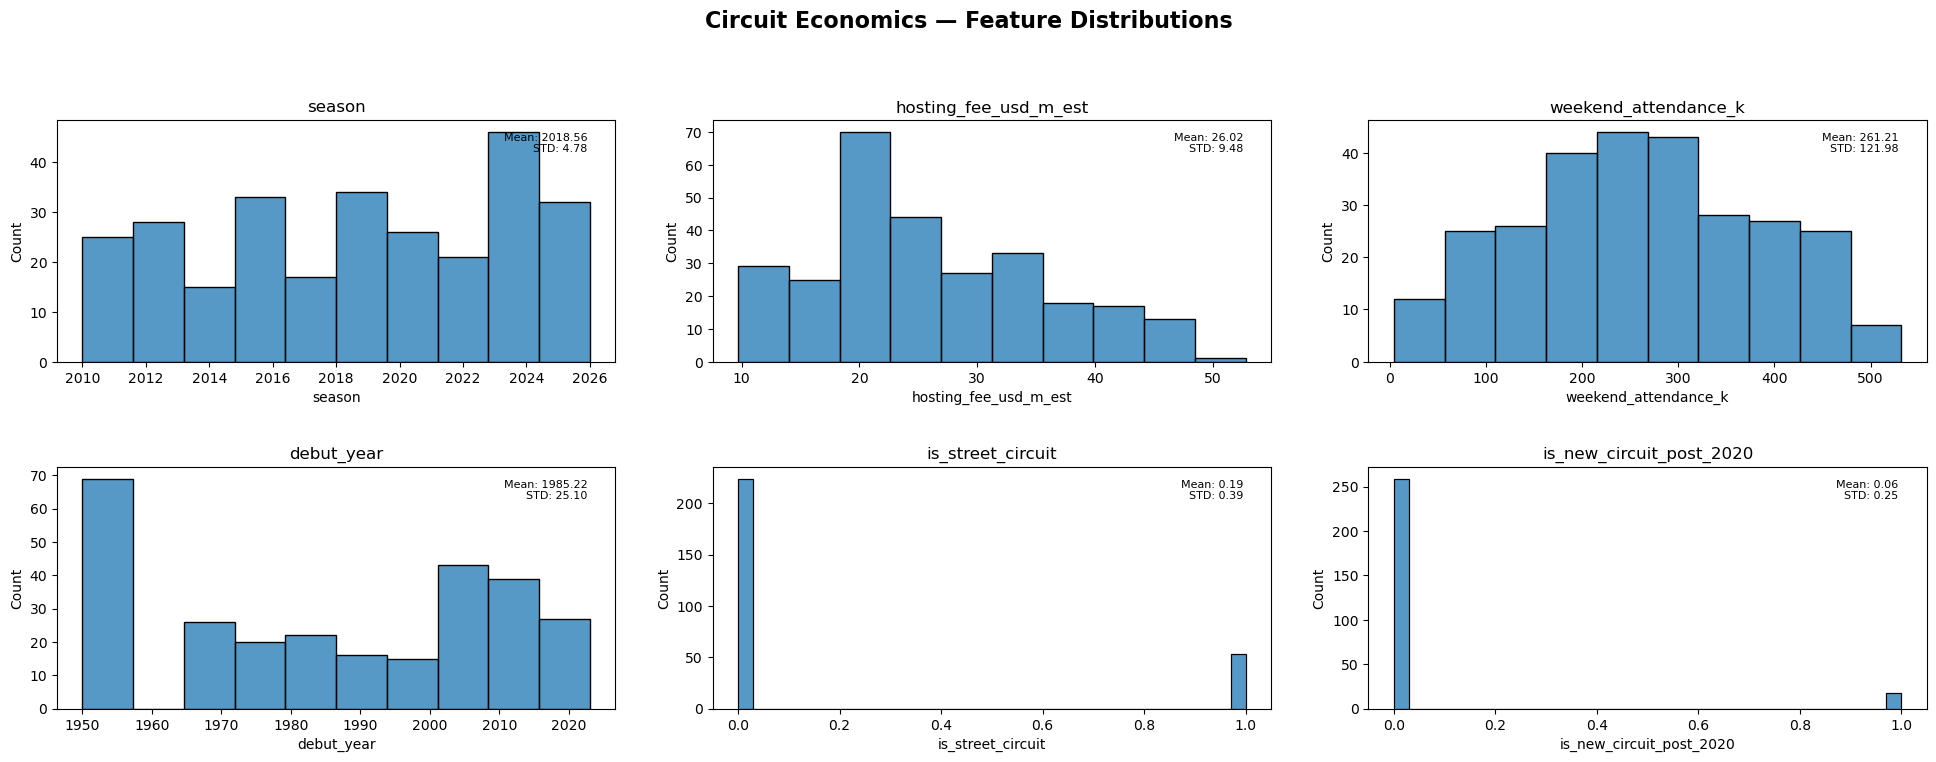

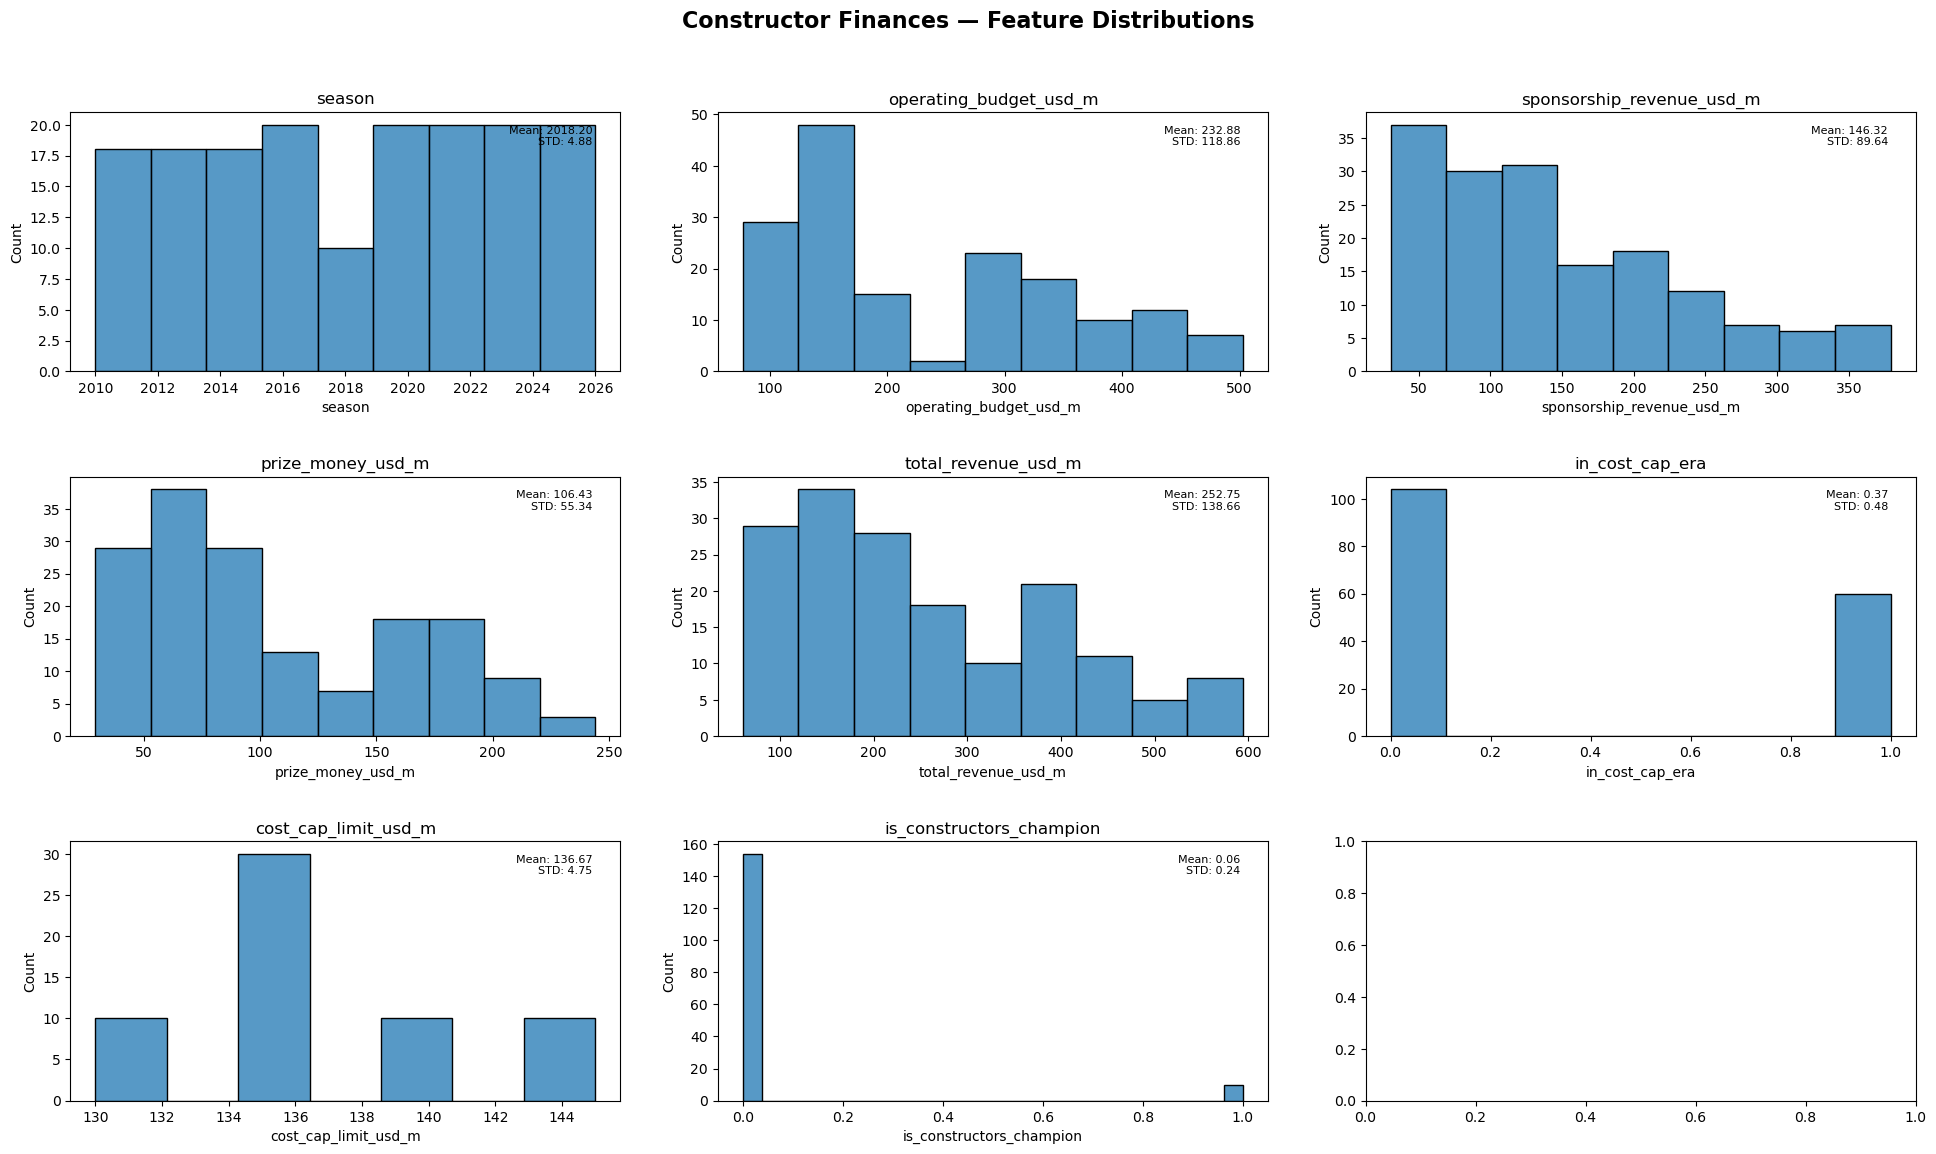

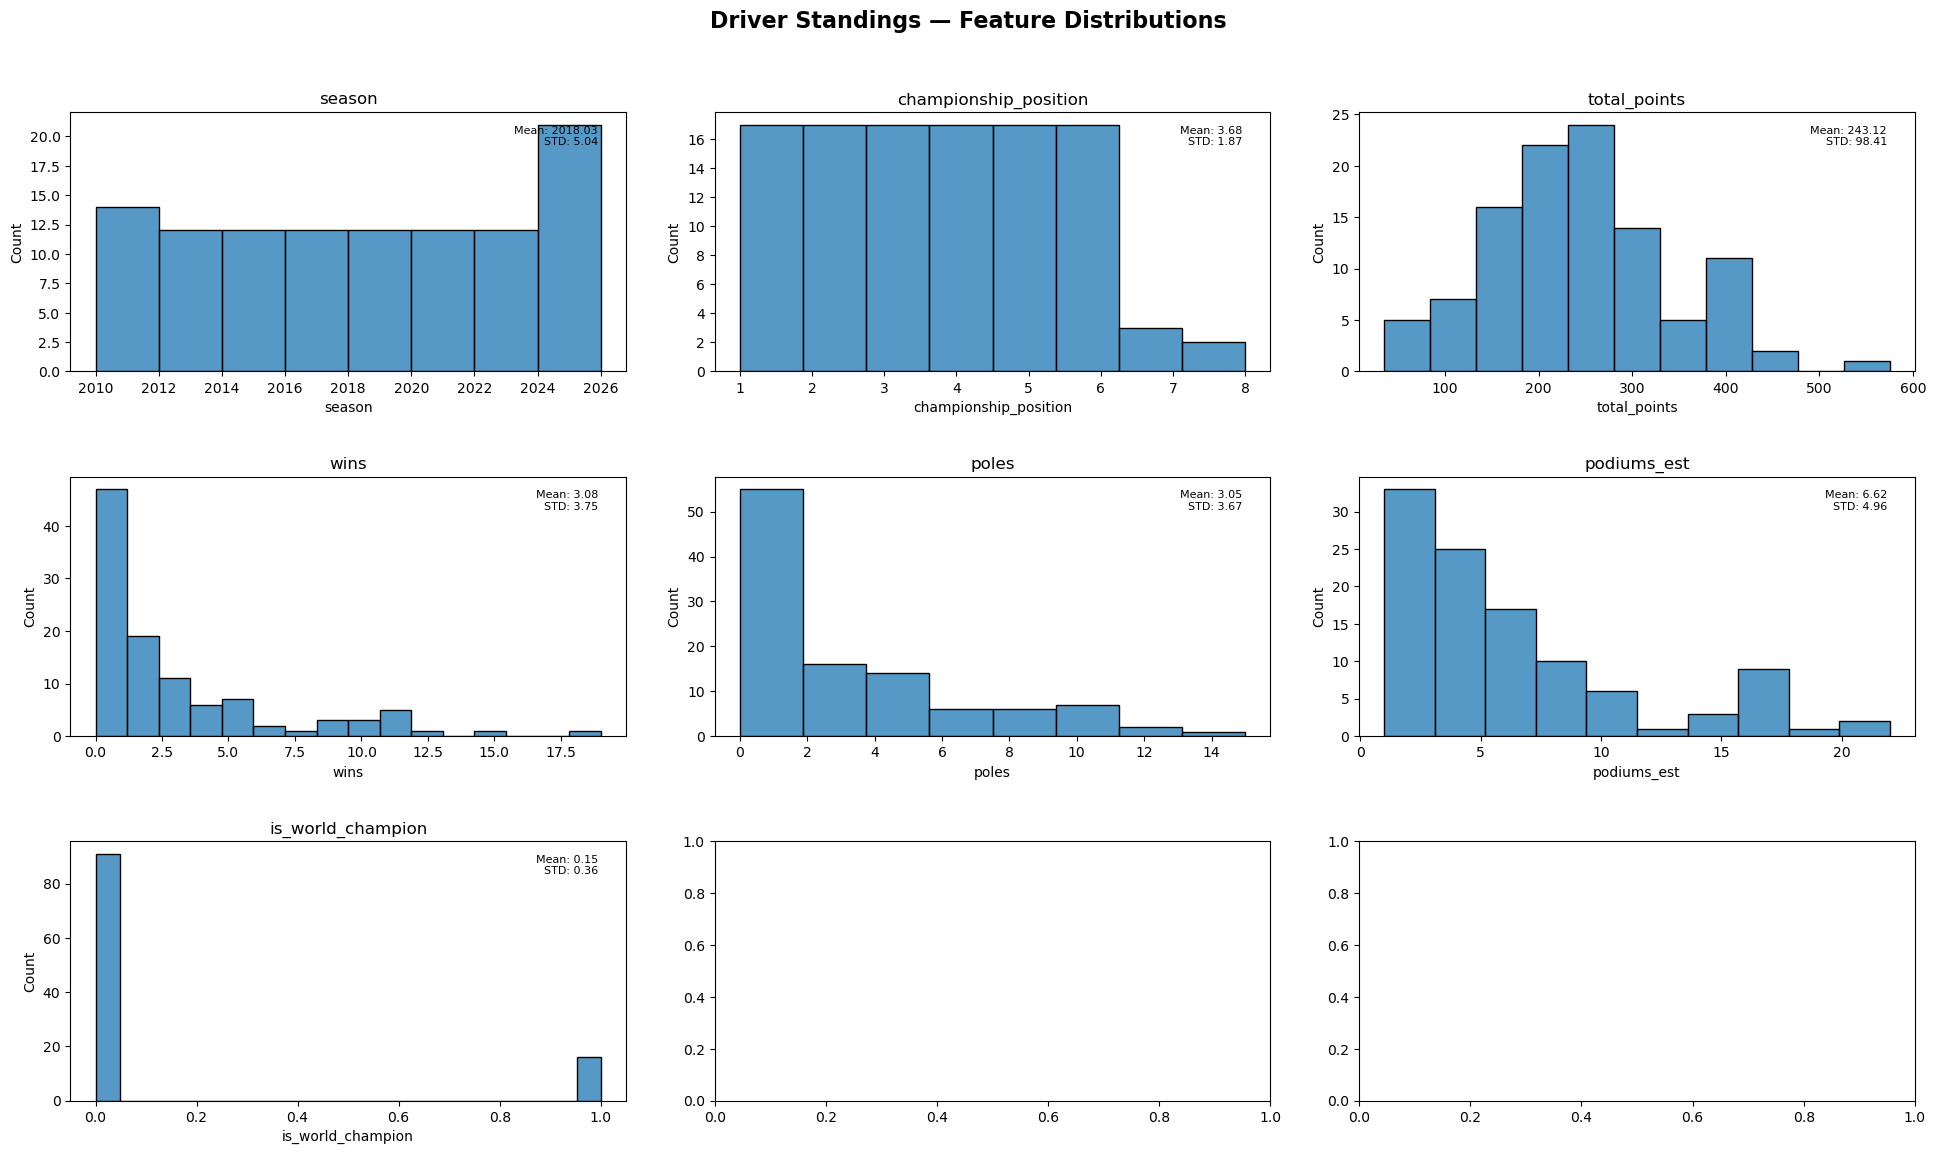

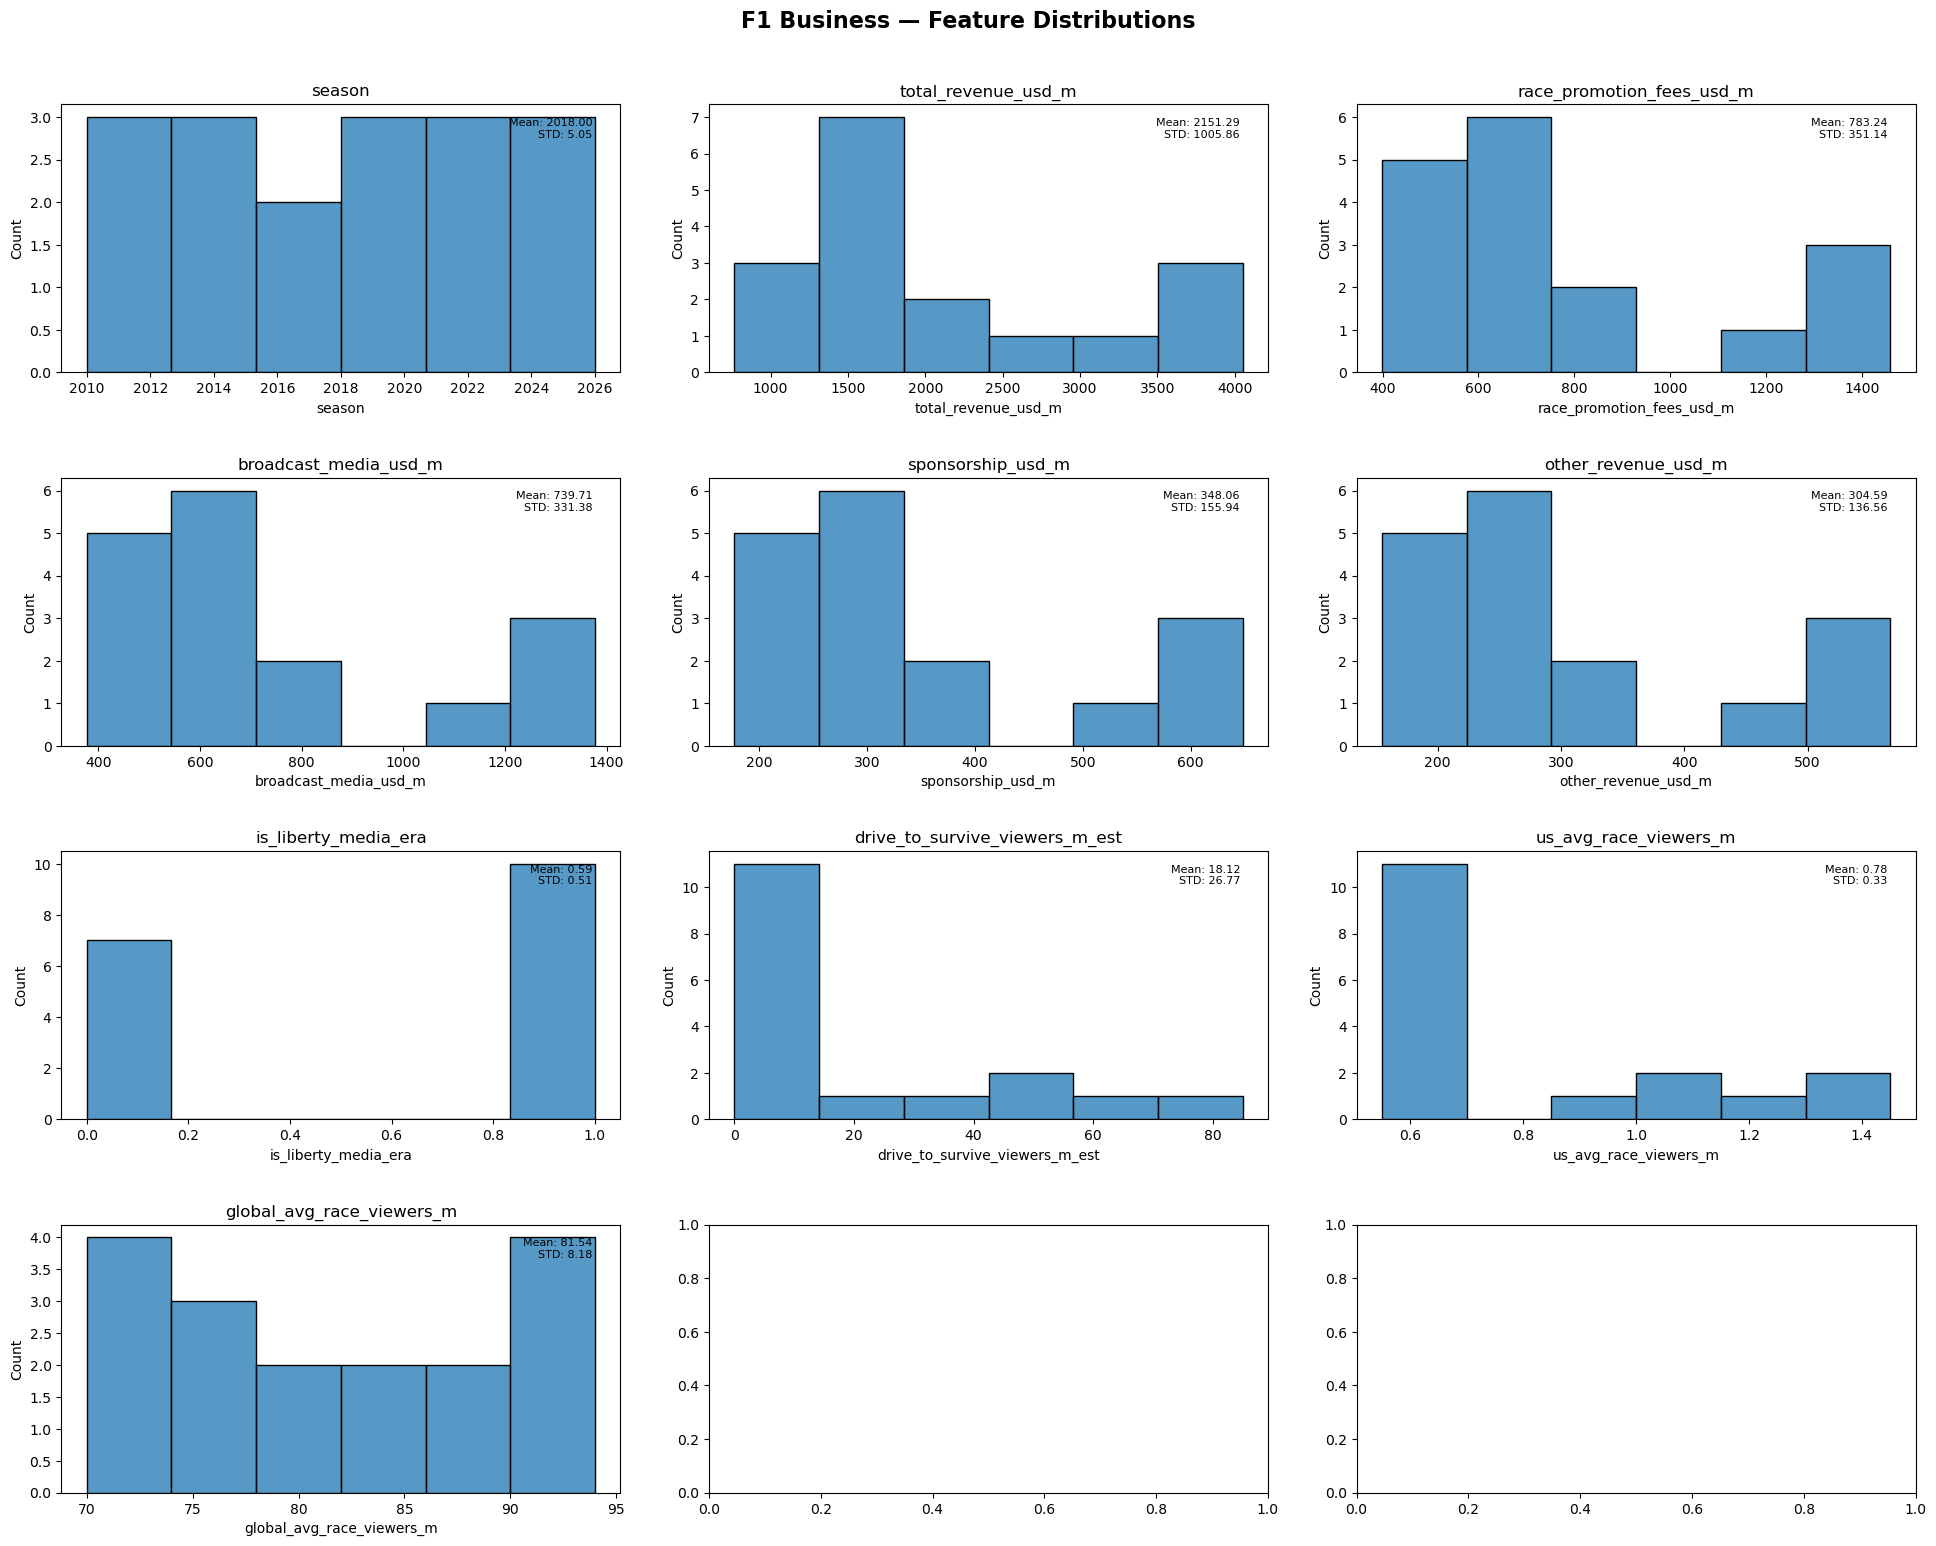

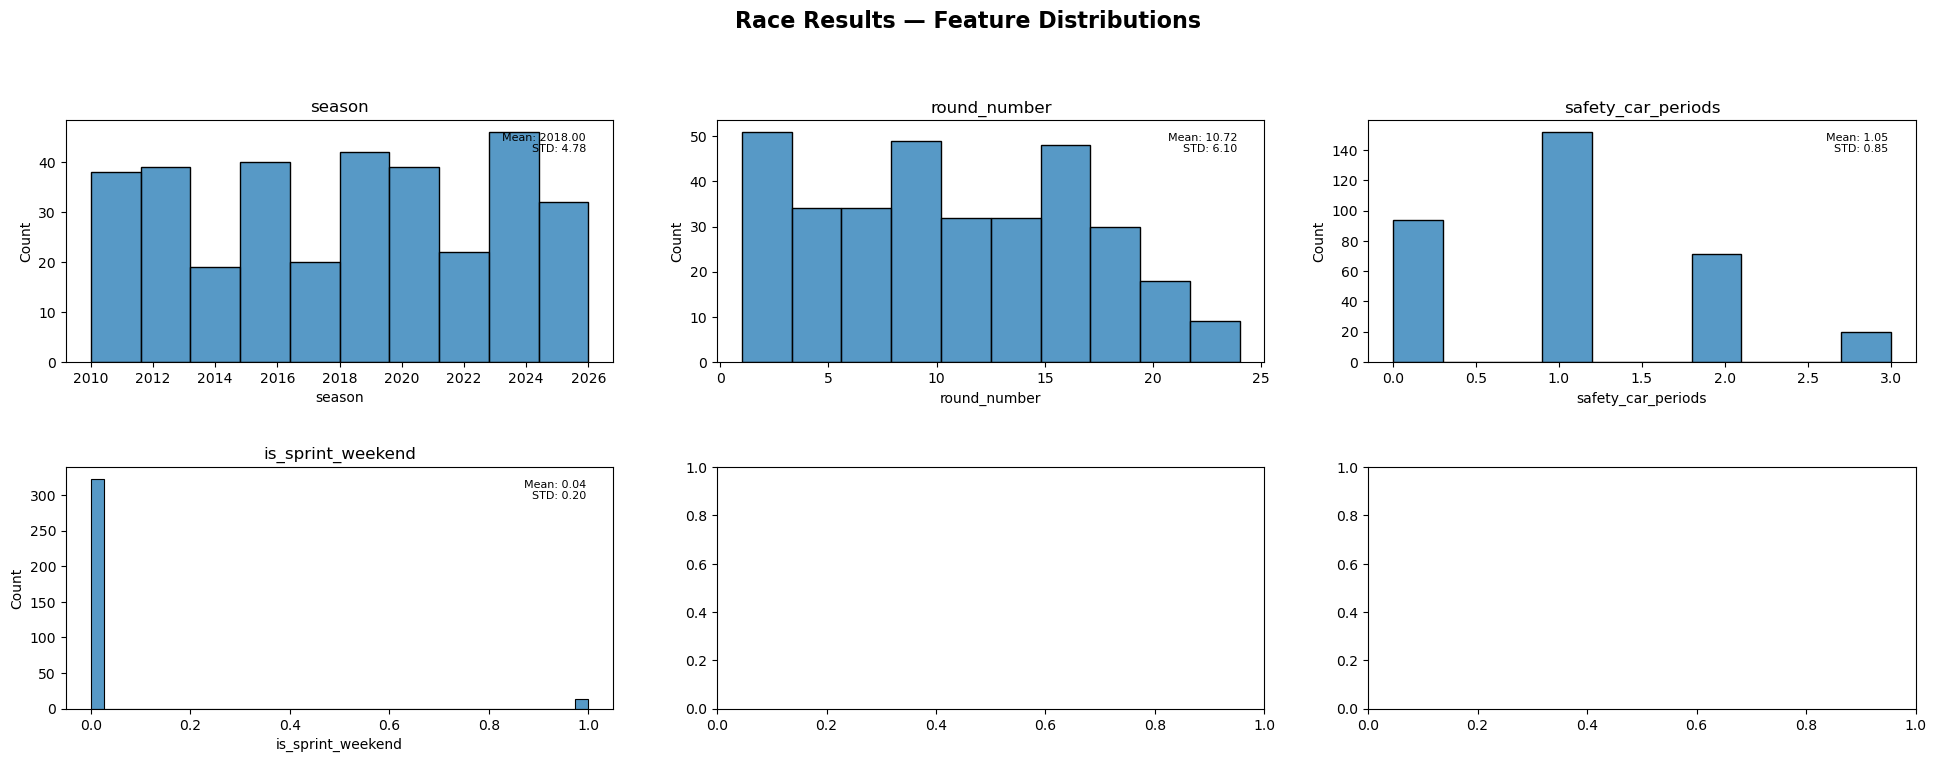

In [18]:
datasets = {
    "Circuit Economics": circuit_eco,
    "Constructor Finances": construction,
    "Driver Standings": standing,
    "F1 Business": business,
    "Race Results": results}

for dataset_name,df in datasets.items():
    numeric_cols = df.select_dtypes(include = "number").columns.tolist()
    
    if len(numeric_cols)==0:
        continue

    n_cols = 3
    n_rows = (len(numeric_cols)+n_cols-1)//n_cols

    fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    ax = ax.flatten()
    
    fig.suptitle(f"{dataset_name} — Feature Distributions", 
                 fontsize=16, fontweight="bold")
    for i,col in enumerate(numeric_cols):
        mean = df[col].mean()
        std = df[col].std()
        sns.histplot(data=df, x=col, ax=ax[i])
        ax[i].set_title(col)
        ax[i].text(0.95, 0.95, f"Mean: {mean:.2f}\nSTD: {std:.2f}",
                   transform=ax[i].transAxes, ha="right", va="top", fontsize=8)
    
    plt.tight_layout(pad=3.0)
    plt.savefig(f"charts/{dataset_name.replace(' ', '_')}_distributions.png",
                bbox_inches="tight", dpi=150)
    plt.show()    

## 3.2 Financial & Business Performance Analysis

/var/folders/r7/5wz764v55ng1wynsd3fhbk4c0000gn/T/ipykernel_6629/3109605878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = winning_driver["wins"],
/var/folders/r7/5wz764v55ng1wynsd3fhbk4c0000gn/T/ipykernel_6629/3109605878.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = driver_points["total_points"],
/var/folders/r7/5wz764v55ng1wynsd3fhbk4c0000gn/T/ipykernel_6629/3109605878.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = driver_champ["is_world_champion"],


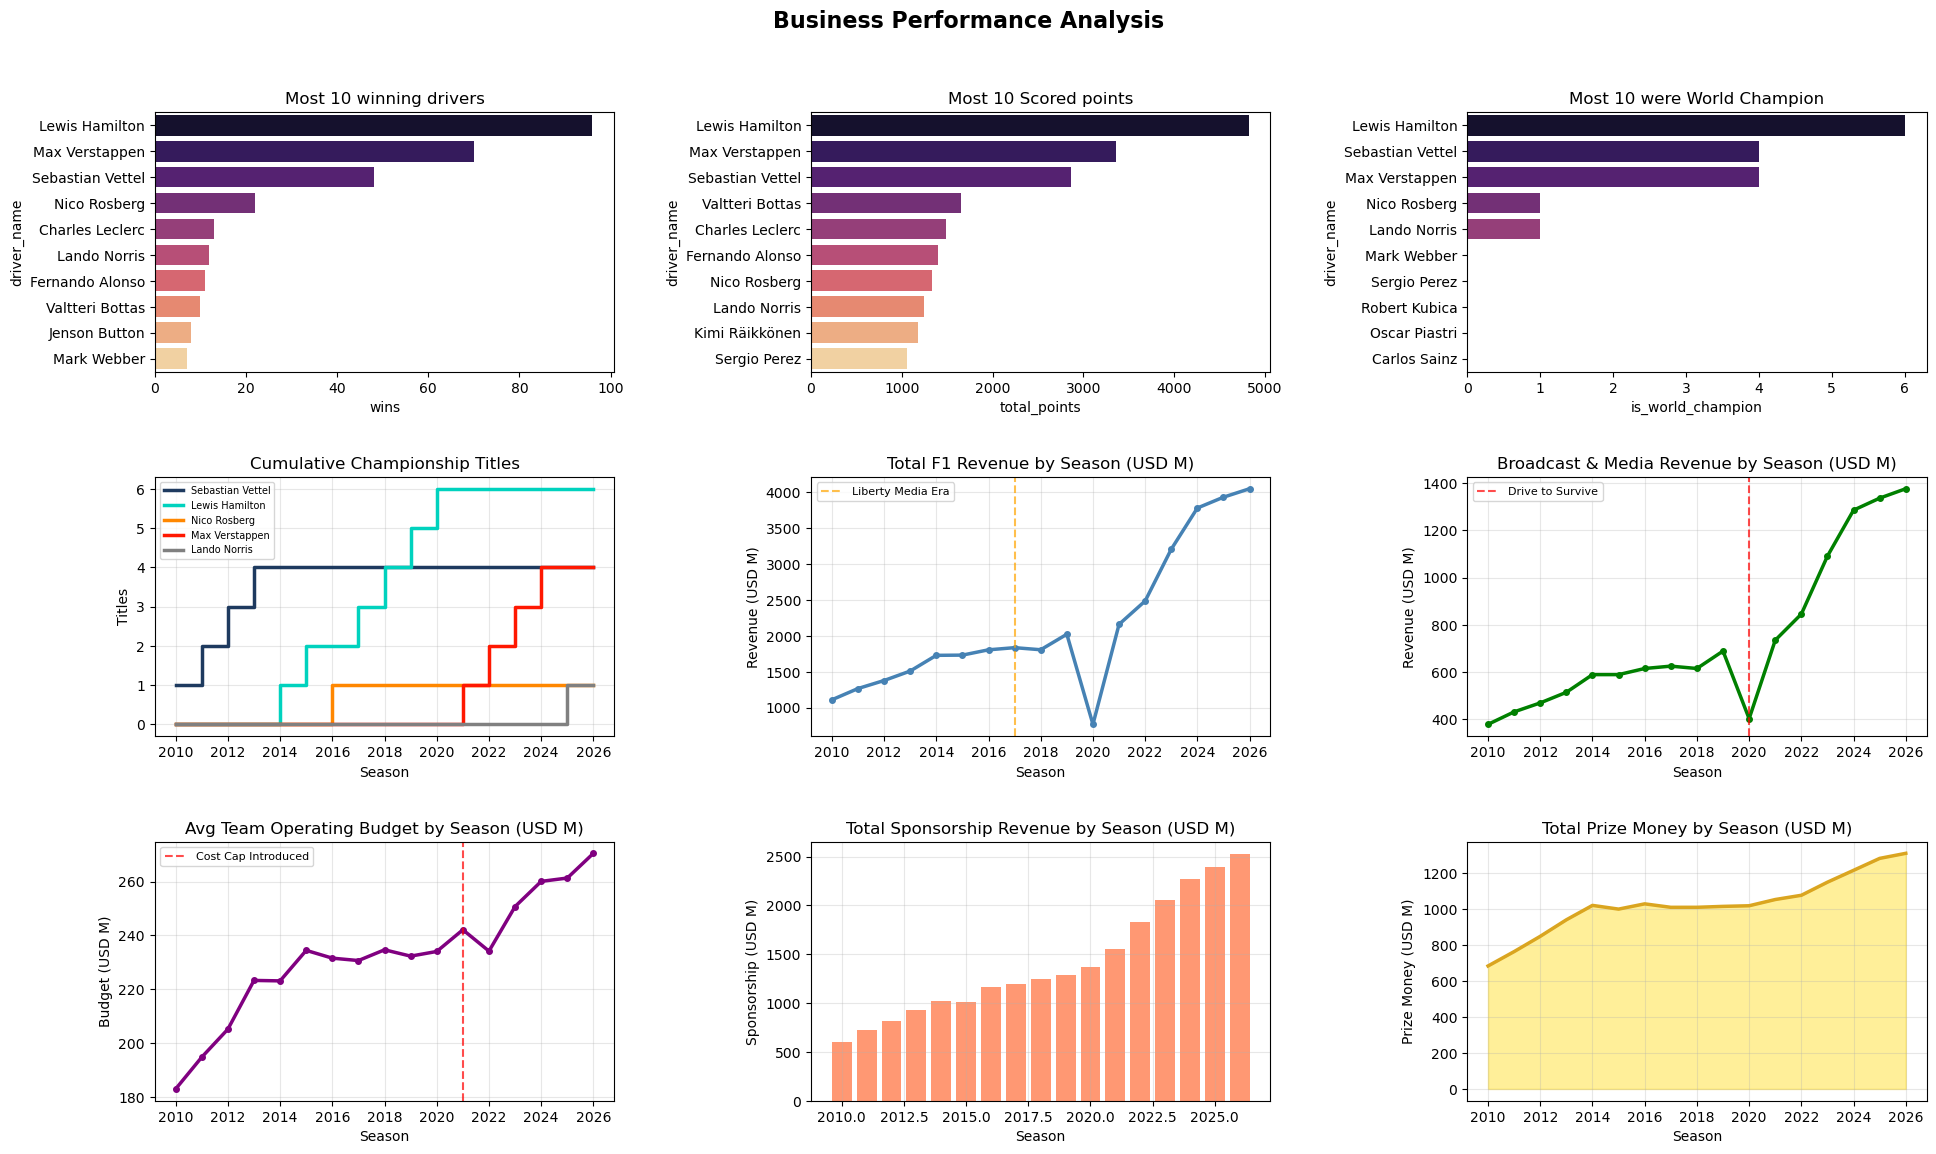

In [19]:
fig,ax = plt.subplots(3,3,figsize=(20,12))
ax = ax.flatten()
fig.suptitle("Business Performance Analysis", fontsize=16, fontweight="bold")

# 1. the Most 10 winning drivers 
winning_driver = standing.groupby("driver_name")["wins"].sum().reset_index().sort_values("wins", ascending=False).head(10)
sns.barplot(x = winning_driver["wins"],
            y = winning_driver["driver_name"],
            ax = ax[0],
           palette="magma")
ax[0].set_title("Most 10 winning drivers")

# 2. the most 10 driveres scoed points
driver_points = standing.groupby("driver_name")["total_points"].sum().reset_index().sort_values("total_points", ascending=False).head(10)
sns.barplot(x = driver_points["total_points"],
            y = driver_points["driver_name"],
            ax = ax[1],
            palette = "magma")
ax[1].set_title("Most 10 Scored points")
plt.tight_layout(pad = 3.0)

# 3. the most 10 driveres were world champions
driver_champ = standing.groupby("driver_name")["is_world_champion"].sum().reset_index().sort_values("is_world_champion", ascending=False).head(10)
sns.barplot(x = driver_champ["is_world_champion"],
            y = driver_champ["driver_name"],
            ax = ax[2],
            palette = "magma")
ax[2].set_title("Most 10 were World Champion")

# 4. World Championship titles timeline
champions = standing[standing["is_world_champion"] == 1][["season","driver_name"]].sort_values("season")
all_seasons = sorted(standing["season"].unique())
title_winners = champions["driver_name"].unique()

cumulative = []
for driver in title_winners:
    titles = 0
    for season in all_seasons:
        if ((champions["season"] == season) & 
            (champions["driver_name"] == driver)).any():
            titles += 1
        cumulative.append({        # ← append INSIDE season loop
            "season": season,
            "driver": driver,
            "cumulative_titles": titles
        })

df_cumulative = pd.DataFrame(cumulative)

colors = {
    "Sebastian Vettel": "#1E3A5F",
    "Lewis Hamilton": "#00D2BE",
    "Nico Rosberg": "#FF8700",
    "Max Verstappen": "#FF1801"
}

for driver in title_winners:
    data = df_cumulative[df_cumulative["driver"] == driver]
    color = colors.get(driver, "gray")
    ax[3].step(data["season"],
               data["cumulative_titles"],
               where="post",
               linewidth=2.5,
               label=driver,
               color=color)

ax[3].set_title("Cumulative Championship Titles")
ax[3].set_xlabel("Season")
ax[3].set_ylabel("Titles")
ax[3].legend(fontsize=7)
ax[3].grid(True, alpha=0.3)

# 5. Total F1 Revenue by Season
revenue_season = business.groupby("season")["total_revenue_usd_m"].sum().reset_index()
ax[4].plot(revenue_season["season"], revenue_season["total_revenue_usd_m"],
           color="steelblue", linewidth=2.5, marker="o", markersize=4)
ax[4].axvline(x=2017, color="orange", linestyle="--", alpha=0.7, label="Liberty Media Era")
ax[4].set_title("Total F1 Revenue by Season (USD M)")
ax[4].set_xlabel("Season")
ax[4].set_ylabel("Revenue (USD M)")
ax[4].legend(fontsize=8)
ax[4].grid(True, alpha=0.3)

# 6. Broadcast & Media Revenue by Season
broadcast_season = business.groupby("season")["broadcast_media_usd_m"].sum().reset_index()
ax[5].plot(broadcast_season["season"], broadcast_season["broadcast_media_usd_m"],
           color="green", linewidth=2.5, marker="o", markersize=4)
ax[5].axvline(x=2020, color="red", linestyle="--", alpha=0.7, label="Drive to Survive")
ax[5].set_title("Broadcast & Media Revenue by Season (USD M)")
ax[5].set_xlabel("Season")
ax[5].set_ylabel("Revenue (USD M)")
ax[5].legend(fontsize=8)
ax[5].grid(True, alpha=0.3)

# 7. Average Operating Budget by Season
budget_season = construction.groupby("season")["operating_budget_usd_m"].mean().reset_index()
ax[6].plot(budget_season["season"], budget_season["operating_budget_usd_m"],
           color="purple", linewidth=2.5, marker="o", markersize=4)
ax[6].axvline(x=2021, color="red", linestyle="--", alpha=0.7, label="Cost Cap Introduced")
ax[6].set_title("Avg Team Operating Budget by Season (USD M)")
ax[6].set_xlabel("Season")
ax[6].set_ylabel("Budget (USD M)")
ax[6].legend(fontsize=8)
ax[6].grid(True, alpha=0.3)

# 8. Sponsorship Revenue by Season
sponsorship_season = construction.groupby("season")["sponsorship_revenue_usd_m"].sum().reset_index()
ax[7].bar(sponsorship_season["season"], sponsorship_season["sponsorship_revenue_usd_m"],
          color="coral", alpha=0.8)
ax[7].set_title("Total Sponsorship Revenue by Season (USD M)")
ax[7].set_xlabel("Season")
ax[7].set_ylabel("Sponsorship (USD M)")
ax[7].grid(True, alpha=0.3)

# 9. Prize Money Distribution by Season
prize_season = construction.groupby("season")["prize_money_usd_m"].sum().reset_index()
ax[8].fill_between(prize_season["season"], prize_season["prize_money_usd_m"],
                    alpha=0.4, color="gold")
ax[8].plot(prize_season["season"], prize_season["prize_money_usd_m"],
           color="goldenrod", linewidth=2.5)
ax[8].set_title("Total Prize Money by Season (USD M)")
ax[8].set_xlabel("Season")
ax[8].set_ylabel("Prize Money (USD M)")
ax[8].grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig("charts/financial_timeseries.png", bbox_inches="tight", dpi=150)
plt.show()

## 3.3 Correlation Analysis 

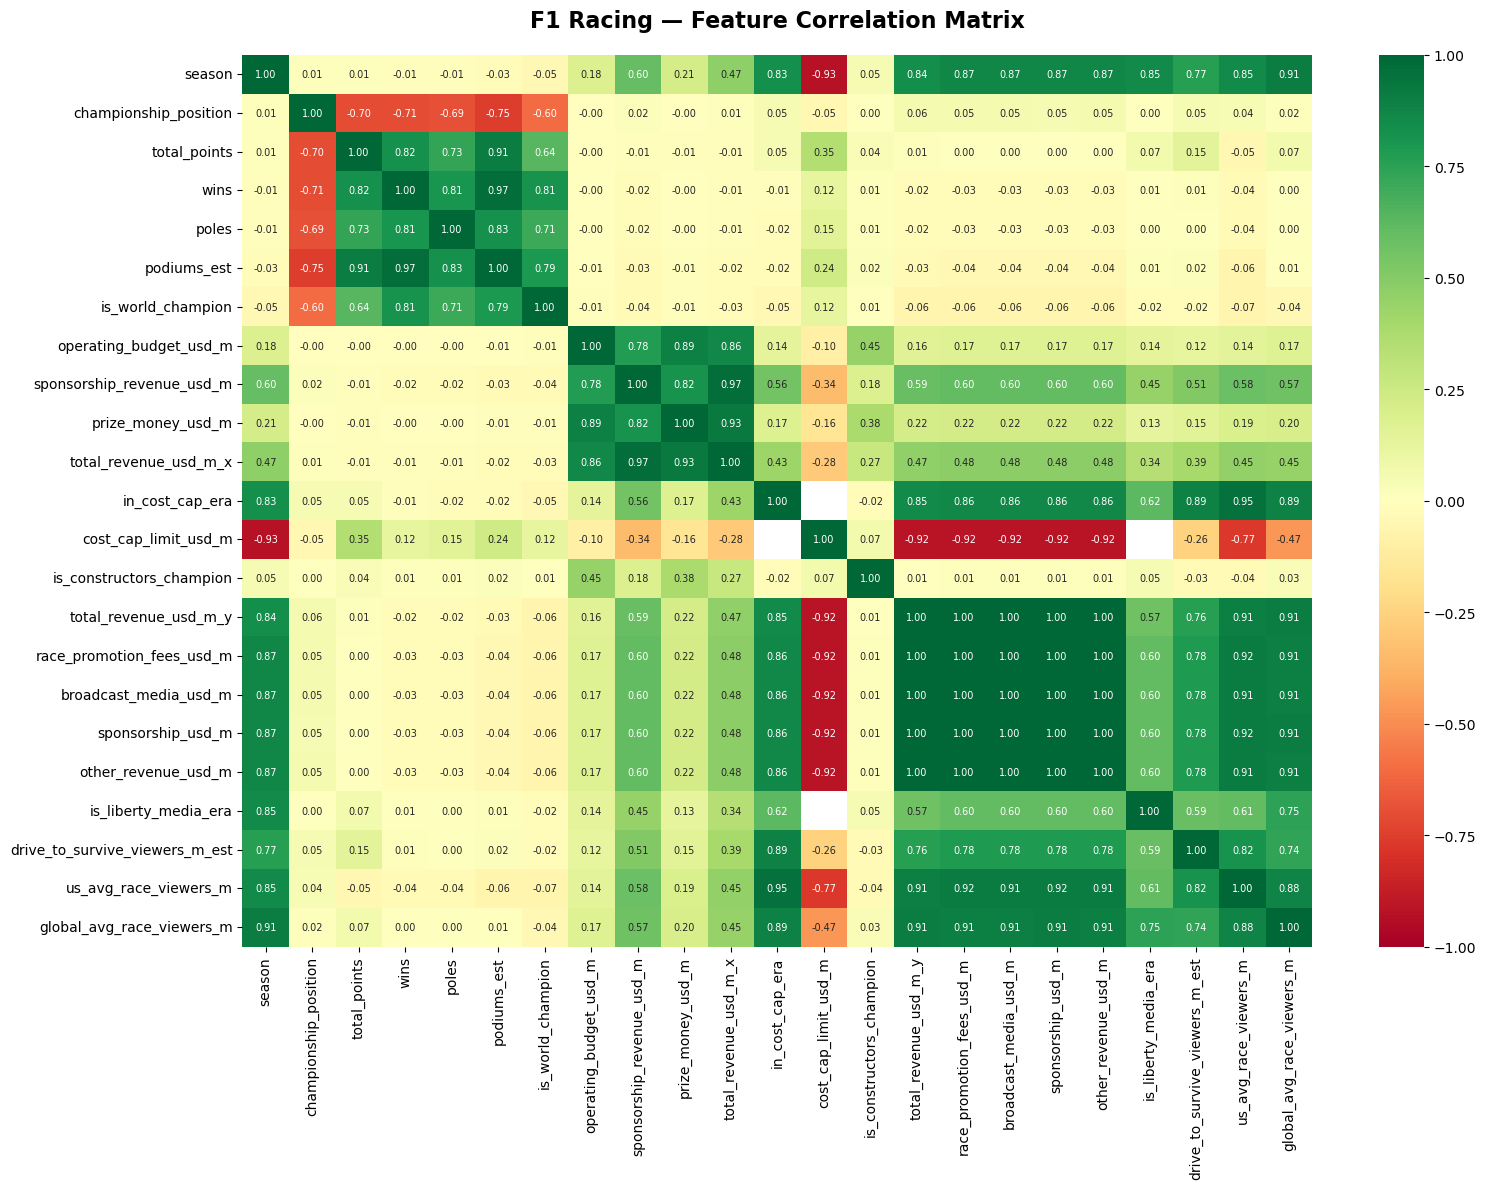

In [20]:
merged = standing.merge(construction, on="season", how="left")
merged = merged.merge(business, on="season", how="left")

numeric_merged = merged.select_dtypes(include="number")

fig, ax = plt.subplots(figsize=(16, 12))

corr = numeric_merged.corr()

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            annot_kws={"size": 7},
            cmap="RdYlGn",
            center=0,
            vmin=-1, vmax=1,
            ax=ax)

ax.set_title("F1 Racing — Feature Correlation Matrix",
             fontsize=16, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("charts/correlation_matrix.png", bbox_inches="tight", dpi=150)
plt.show()

# 4. preprocessing

## 4.1 Fill the Missing values

In [21]:
print(standing.isnull().sum())
print(construction.isnull().sum())
print(results.isnull().sum())
print(business.isnull().sum())
print(circuit_eco.isnull().sum())

season                   0
championship_position    0
driver_name              0
country_iso3             0
total_points             0
wins                     0
poles                    0
podiums_est              0
is_world_champion        0
dtype: int64
season                         0
team_name                      0
country_iso3                   0
operating_budget_usd_m         0
sponsorship_revenue_usd_m      0
prize_money_usd_m              0
total_revenue_usd_m            0
in_cost_cap_era                0
cost_cap_limit_usd_m         104
is_constructors_champion       0
dtype: int64
race_id               0
season                0
round_number          0
race_date             0
grand_prix            0
circuit               0
country_iso3          0
region                0
pole_position         0
winner                0
podium_p2             0
podium_p3             0
fastest_lap_driver    0
safety_car_periods    0
is_sprint_weekend     0
dtype: int64
season                      

In [22]:
construction["cost_cap_limit_usd_m"] = construction["cost_cap_limit_usd_m"].fillna(0)

## 4.2 Encoding

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le = LabelEncoder()

In [25]:
datasets = {
    "Circuit Economics": circuit_eco,
    "Constructor Finances": construction,
    "Driver Standings": standing,
    "F1 Business": business,
    "Race Results": results}

In [26]:
for name, df in datasets.items():
    obj_cols = df.select_dtypes(include="object").columns.tolist()
    print(f"\n{name} — encoding: {obj_cols}")

    for col in obj_cols :
        df[col + "_encoded"] = le.fit_transform(df[col])
        print(f" {col} → {col}_encoded")


Circuit Economics — encoding: ['grand_prix', 'circuit', 'country_iso3', 'region']
 grand_prix → grand_prix_encoded
 circuit → circuit_encoded
 country_iso3 → country_iso3_encoded
 region → region_encoded

Constructor Finances — encoding: ['team_name', 'country_iso3']
 team_name → team_name_encoded
 country_iso3 → country_iso3_encoded

Driver Standings — encoding: ['driver_name', 'country_iso3']
 driver_name → driver_name_encoded
 country_iso3 → country_iso3_encoded

F1 Business — encoding: []

Race Results — encoding: ['race_id', 'race_date', 'grand_prix', 'circuit', 'country_iso3', 'region', 'pole_position', 'winner', 'podium_p2', 'podium_p3', 'fastest_lap_driver']
 race_id → race_id_encoded
 race_date → race_date_encoded
 grand_prix → grand_prix_encoded
 circuit → circuit_encoded
 country_iso3 → country_iso3_encoded
 region → region_encoded
 pole_position → pole_position_encoded
 winner → winner_encoded
 podium_p2 → podium_p2_encoded
 podium_p3 → podium_p3_encoded
 fastest_lap_drive

In [27]:
results["race_date"] = pd.to_datetime(results["race_date"])
results = results.drop(columns=["race_date_encoded", "race_id_encoded"])

## 4.3 Train Test Split

In [28]:
x = construction.drop(columns=["total_revenue_usd_m", "team_name", "country_iso3"])
y = construction["total_revenue_usd_m"]

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
split_idx = int(len(construction)*0.80)
x_train = x.iloc[:split_idx]
x_test = x.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# 5. Model

In [31]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [32]:
models = {"RandomForestRegressor":RandomForestRegressor(random_state=42),
         "XGBRegressor":XGBRegressor(random_state=42),
         "LGBMRegressor":LGBMRegressor(random_state=42, verbose=-1)}

# 6. Evaluation

In [33]:
for name,model in models.items():
    pipe = Pipeline([("scaler",StandardScaler()),
                    ("model",model)])
    pipe.fit(x_train,y_train)
    print(pipe.score(x_train,y_train))
    y_pred = pipe.predict(x_test)

    R2 = r2_score(y_test,y_pred)
    mae = mean_absolute_error(y_test,y_pred)
    msr = mean_squared_error(y_test,y_pred)

    print (f"Name: {name}  R2: {R2:.3f}")
    print (f"Name: {name}  MAE: {mae:.3f}")
    print (f"Name: {name}  MSR: {msr:.3f}")

0.9983146041883791
Name: RandomForestRegressor  R2: 0.970
Name: RandomForestRegressor  MAE: 8.127
Name: RandomForestRegressor  MSR: 111.330
0.9999999932253364
Name: XGBRegressor  R2: 0.977
Name: XGBRegressor  MAE: 7.080
Name: XGBRegressor  MSR: 86.036
0.9925207012923124
Name: LGBMRegressor  R2: 0.936
Name: LGBMRegressor  MAE: 11.929
Name: LGBMRegressor  MSR: 237.593


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


# 7. Model Result Analysis

In [34]:
print(x.columns)

Index(['season', 'operating_budget_usd_m', 'sponsorship_revenue_usd_m',
       'prize_money_usd_m', 'in_cost_cap_era', 'cost_cap_limit_usd_m',
       'is_constructors_champion', 'team_name_encoded',
       'country_iso3_encoded'],
      dtype='object')


In [35]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [36]:
final_model = models["XGBRegressor"]
y_pred = final_model.predict(x_test)

In [37]:
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle("F1 Team Revenue Prediction — Model Evaluation",
             fontsize=18, fontweight="bold")

# 1. Actual vs Predicted 
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred, color="steelblue", alpha=0.7)
ax1.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", linewidth=2, label="Perfect prediction")
ax1.set_title("Actual vs Predicted Revenue")
ax1.set_xlabel("Actual Revenue (USD M)")
ax1.set_ylabel("Predicted Revenue (USD M)")
ax1.legend()

# 2. Residuals Plot
ax2 = fig.add_subplot(gs[0, 1])
residuals = y_test - y_pred
ax2.scatter(y_pred, residuals, color="coral", alpha=0.7)
ax2.axhline(y=0, color="black", linestyle="--")
ax2.set_title("Residuals Plot")
ax2.set_xlabel("Predicted Revenue (USD M)")
ax2.set_ylabel("Residuals")

# 3. Feature Importance 
ax3 = fig.add_subplot(gs[0, 2])
if hasattr(final_model, "named_steps"):
    importances = final_model.named_steps["model"].feature_importances_
else:
    importances = final_model.feature_importances_

importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": importances
}).sort_values("Importance", ascending=True)

ax3.barh(importance["Feature"], importance["Importance"], color="steelblue")
ax3.set_title("Feature Importance")
ax3.set_xlabel("Importance Score")

# 4. Model Comparison 
ax4 = fig.add_subplot(gs[1, 0])
model_names = list(models.keys())
r2_scores = [r2_score(y_test, m.predict(x_test)) for m in models.values()]
colors = ["#d9534f", "#f0ad4e", "#5cb85c"]
bars = ax4.bar(model_names, r2_scores, color=colors)
ax4.set_ylim(0, 1)
ax4.set_title("Model Comparison — R²")
ax4.set_ylabel("R² Score")
for bar, score in zip(bars, r2_scores):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{score:.4f}", ha="center", fontsize=9, fontweight="bold")

# 5. Actual vs Predicted Time Series 
ax5 = fig.add_subplot(gs[1, 1])
test_seasons = construction.iloc[split_idx:]["season"].values
ax5.plot(test_seasons, y_test.values, 
         marker="o", linewidth=2, label="Actual", color="steelblue")
ax5.plot(test_seasons, y_pred, 
         marker="s", linewidth=2, label="Predicted", 
         color="coral", linestyle="--")
ax5.set_title("Actual vs Predicted by Season")
ax5.set_xlabel("Season")
ax5.set_ylabel("Revenue (USD M)")
ax5.legend()

# 6. Metrics Table 
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
metrics_data = []
for name, model in models.items():
    pred = model.predict(x_test)
    metrics_data.append([
        name,
        f"{r2_score(y_test, pred):.4f}",
        f"{mean_absolute_error(y_test, pred):.2f}",
        f"{np.sqrt(mean_squared_error(y_test, pred)):.2f}"
    ])

table = ax6.table(
    cellText=metrics_data,
    colLabels=["Model", "R²", "MAE", "RMSE"],
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
ax6.set_title("Metrics Summary", fontweight="bold")

plt.tight_layout(pad =3.0)
plt.savefig("charts/model_evaluation.png", bbox_inches="tight", dpi=150)
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/var/folders/r7/5wz764v55ng1wynsd3fhbk4c0000gn/T/ipykernel_6629/4256969604.py:91: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad =3.0)


# 8. save 

In [38]:
import joblib 
import os

In [39]:
joblib.dump(final_model,"trained_model/final_xgb.pkl")
joblib.dump(x_train.columns.tolist(),"trained_model/feature_names.pkl")
print("done")

done
